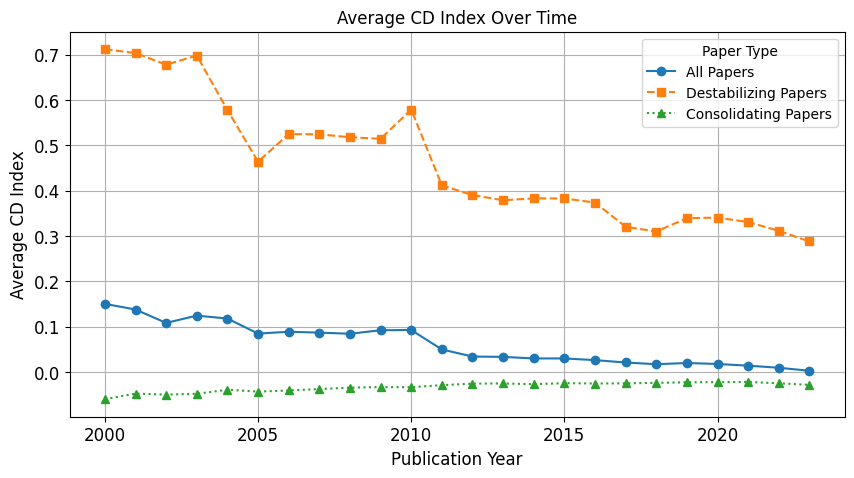

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

data = pd.read_csv('\\Users\\joshu\\Downloads\\UROP_Code\\Data\\graph_data.csv')

average_cd = data.groupby('earliest_pub_year')['CD_Index'].mean().reset_index()

positive_cd = data[data['CD_Index'] > 0].groupby('earliest_pub_year')['CD_Index'].mean().reset_index()
negative_cd = data[data['CD_Index'] < 0].groupby('earliest_pub_year')['CD_Index'].mean().reset_index()

plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(average_cd['earliest_pub_year'], average_cd['CD_Index'], marker='o', linestyle='-', label='All Papers')
ax.plot(positive_cd['earliest_pub_year'], positive_cd['CD_Index'], marker='s', linestyle='--', label='Destabilizing Papers')
ax.plot(negative_cd['earliest_pub_year'], negative_cd['CD_Index'], marker='^', linestyle=':', label='Consolidating Papers')
ax.set_xlabel('Publication Year')
ax.set_ylabel('Average CD Index')
ax.set_title('Average CD Index Over Time')
ax.grid(True)
ax.legend(title='Paper Type', loc='upper right', fontsize=10, framealpha=0.8)
fig.savefig('average_cd_index.png', dpi=300, bbox_inches='tight')

plt.show()


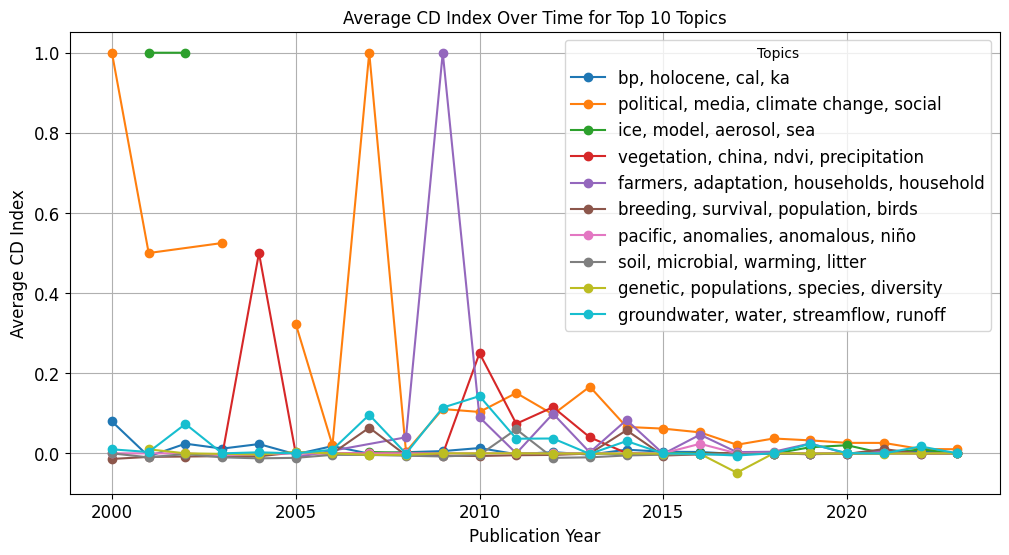

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
def capitalize_after_space(text):
    return " ".join([word[0].upper() + word[1:] if word else "" for word in text.split()])

expanded_rows = []

for _, row in data.dropna(subset=['Name_cleaned']).iterrows():
    # capitalized_topics = [capitalize_after_space(topic) for topic in row['Name_cleaned']]  
    expanded_rows.append({'Topic': row['Name_cleaned'],  
                          'CD_Index': row['CD_Index'], 
                          'Year': row['earliest_pub_year']})

expanded_df = pd.DataFrame(expanded_rows)

top_10_topics = expanded_df['Topic'].value_counts().head(10).index.tolist()

filtered_df = expanded_df[expanded_df['Topic'].isin(top_10_topics)]

average_cd_by_topic_year = filtered_df.groupby(['Year', 'Topic'])['CD_Index'].mean().reset_index()

for topic in top_10_topics:
    topic_data = average_cd_by_topic_year[average_cd_by_topic_year['Topic'] == topic]
    ax.plot(topic_data['Year'], topic_data['CD_Index'], marker='o', linestyle='-', label=topic)

ax.set_xlabel('Publication Year')
ax.set_ylabel('Average CD Index')
ax.set_title('Average CD Index Over Time for Top 10 Topics')
ax.legend(title='Topics', loc='upper right', framealpha=0.8)
ax.grid(True)

fig.savefig('top10_topics_cd_index.png', dpi=300, bbox_inches='tight')

plt.show()

C:\Users\joshu\AppData\Local\Temp\ipykernel_44680\1880736983.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


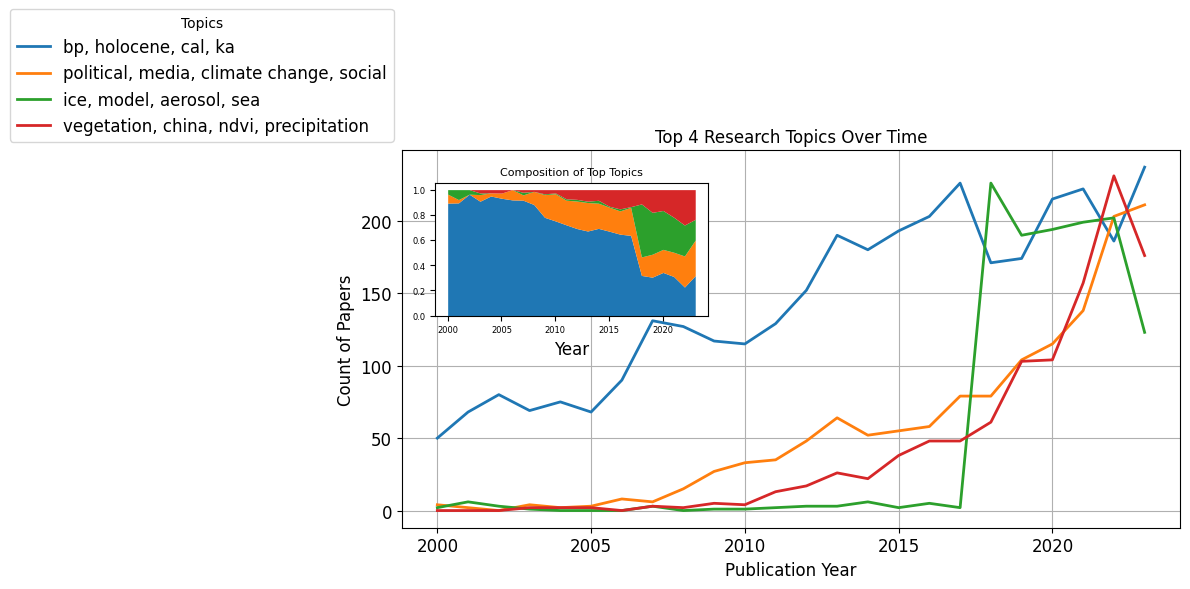

In [14]:
top_4_topics = expanded_df['Topic'].value_counts().head(4).index.tolist()
filtered_top4 = expanded_df[expanded_df['Topic'].isin(top_4_topics)]

paper_counts = filtered_top4.groupby(['Year', 'Topic']).size().reset_index(name='count')

paper_pivot = paper_counts.pivot(index='Year', columns='Topic', values='count').fillna(0)

paper_pivot = paper_pivot[top_4_topics]

fig, ax = plt.subplots(figsize=(12, 6))
paper_pivot.plot(ax=ax, linewidth=2)

ax.set_title('Top 4 Research Topics Over Time')
ax.set_xlabel('Publication Year')
ax.set_ylabel('Count of Papers')
ax.grid(True)
ax.legend(title='Topics', loc='lower right', bbox_to_anchor=(0, 1))

composition = paper_pivot.div(paper_pivot.sum(axis=1), axis=0)
inset_ax = inset_axes(ax, width="35%", height="35%", loc='upper left', borderpad=2)
composition.plot.area(ax=inset_ax, stacked=True, linewidth=0, legend = False)
inset_ax.set_title("Composition of Top Topics", fontsize=8)
inset_ax.tick_params(labelsize=6)

fig.savefig('top4_topics_counts.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()



C:\Users\joshu\AppData\Local\Temp\ipykernel_44680\3370047332.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


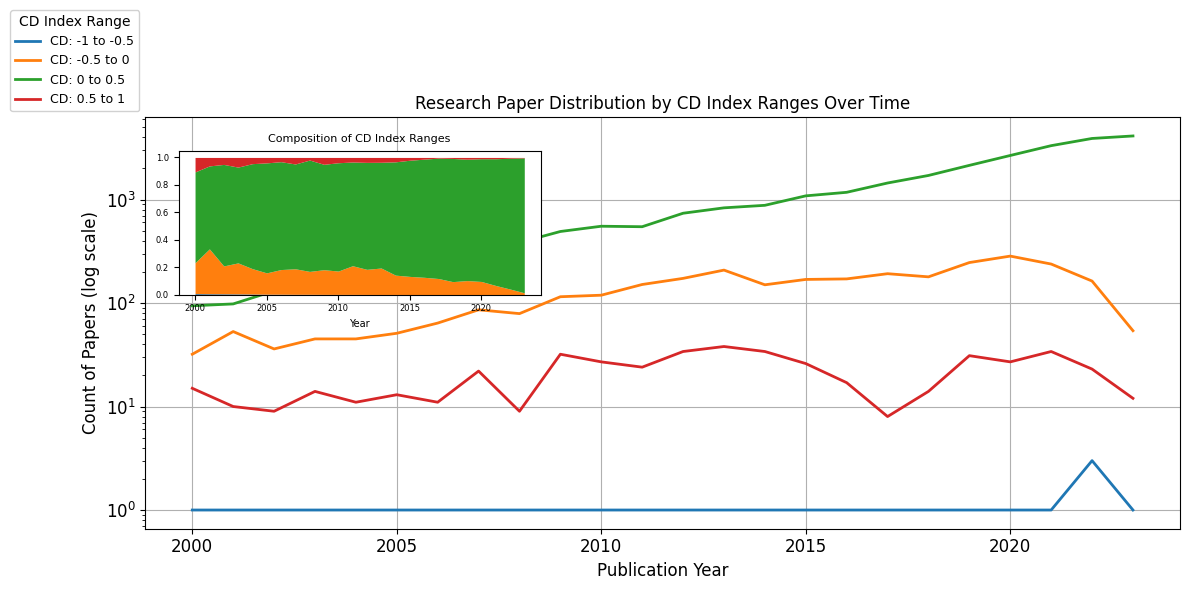

In [17]:
def categorize_cd_index(cd_index):
    if -1 <= cd_index < -.5:
        return 'CD: -1 to -0.5'
    elif -.5 <= cd_index < 0:
        return 'CD: -0.5 to 0' 
    elif 0 <= cd_index < .5:
        return 'CD: 0 to 0.5'
    elif .5 <= cd_index <= 1:
        return 'CD: 0.5 to 1'
    else:
        return None

expanded_df['CD_Group'] = expanded_df['CD_Index'].apply(categorize_cd_index)
filtered_cd = expanded_df[expanded_df['CD_Group'].notnull()]  # Remove out-of-range values


cd_counts = filtered_cd.groupby(['Year', 'CD_Group']).size().reset_index(name='count')


cd_pivot = cd_counts.pivot(index='Year', columns='CD_Group', values='count').fillna(0)

cd_group_order = ['CD: -1 to -0.5', 'CD: -0.5 to 0', 'CD: 0 to 0.5', 'CD: 0.5 to 1']
cd_pivot = cd_pivot[cd_group_order]

cd_pivot = cd_pivot.mask(cd_pivot == 0, 1)

fig, ax = plt.subplots(figsize=(12, 6))
cd_pivot.plot(ax=ax, linewidth=2)

ax.set_title('Research Paper Distribution by CD Index Ranges Over Time')
ax.set_xlabel('Publication Year')
ax.set_ylabel('Count of Papers (log scale)')
ax.set_yscale('log')
ax.grid(True)
ax.legend(title='CD Index Range', loc='lower right', bbox_to_anchor=(0, 1), fontsize=9, framealpha=0.9)

composition = cd_pivot.div(cd_pivot.sum(axis=1), axis=0)
inset_ax = inset_axes(ax, width="35%", height="35%", loc='upper left', borderpad=2)
composition.plot.area(ax=inset_ax, stacked=True, linewidth=0)

inset_ax.set_title("Composition of CD Index Ranges", fontsize=8)
inset_ax.set_xlabel('Year', fontsize=7)
inset_ax.set_ylabel('')
inset_ax.tick_params(axis='both', labelsize=6)
inset_ax.legend().set_visible(False)

fig.savefig('cd_index_ranges.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

C:\Users\joshu\AppData\Local\Temp\ipykernel_44680\3352314033.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


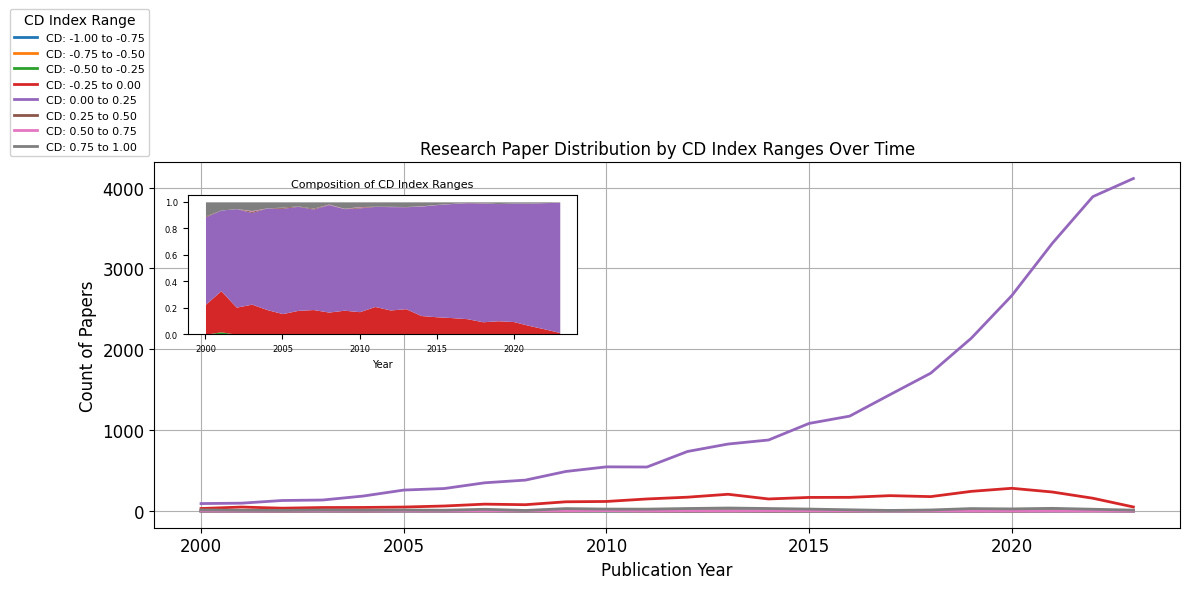

In [18]:
def categorize_cd_index(cd):
    if -1.0 <= cd < -0.75:
        return 'CD: -1.00 to -0.75'
    elif -0.75 <= cd < -0.5:
        return 'CD: -0.75 to -0.50'
    elif -0.5 <= cd < -0.25:
        return 'CD: -0.50 to -0.25'
    elif -0.25 <= cd < 0:
        return 'CD: -0.25 to 0.00'
    elif 0 <= cd < 0.25:
        return 'CD: 0.00 to 0.25'
    elif 0.25 <= cd < 0.5:
        return 'CD: 0.25 to 0.50'
    elif 0.5 <= cd < 0.75:
        return 'CD: 0.50 to 0.75'
    elif 0.75 <= cd <= 1.0:
        return 'CD: 0.75 to 1.00'
    else:
        return None  

expanded_df['CD_Group'] = expanded_df['CD_Index'].apply(categorize_cd_index)
filtered_cd = expanded_df[expanded_df['CD_Group'].notnull()]  

cd_counts = filtered_cd.groupby(['Year', 'CD_Group']).size().reset_index(name='count')
cd_pivot = cd_counts.pivot(index='Year', columns='CD_Group', values='count').fillna(0)

cd_group_order = [
    'CD: -1.00 to -0.75', 'CD: -0.75 to -0.50', 'CD: -0.50 to -0.25', 'CD: -0.25 to 0.00',
    'CD: 0.00 to 0.25', 'CD: 0.25 to 0.50', 'CD: 0.50 to 0.75', 'CD: 0.75 to 1.00'
]
cd_pivot = cd_pivot.reindex(columns=cd_group_order)

fig, ax = plt.subplots(figsize=(12, 6))
cd_pivot.plot(ax=ax, linewidth=2)

ax.set_title('Research Paper Distribution by CD Index Ranges Over Time')
ax.set_xlabel('Publication Year')
ax.set_ylabel('Count of Papers')
ax.grid(True)
ax.legend(title='CD Index Range', loc='lower right', bbox_to_anchor=(0, 1), fontsize=8, framealpha=0.9)

composition = cd_pivot.div(cd_pivot.sum(axis=1), axis=0)
inset_ax = inset_axes(ax, width="38%", height="38%", loc='upper left', borderpad=2)
composition.plot.area(ax=inset_ax, stacked=True, linewidth=0)

inset_ax.set_title("Composition of CD Index Ranges", fontsize=8)
inset_ax.set_xlabel('Year', fontsize=7)
inset_ax.set_ylabel('')
inset_ax.tick_params(axis='both', labelsize=6)
inset_ax.legend().set_visible(False)

fig.savefig('cd_index_ranges_short.png', dpi=300, bbox_inches='tight')


plt.tight_layout()
plt.show()
